# Explore recurring near-boundary location mismatches

This notebook analyzes coordinate mismatch cases already classified as `near_boundary_review` in the two location-review outputs (cross county and cross city reviews). 

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D

data_dir = Path('/Users/oliviakuang/Documents/GitHub/Cloudseeding2')
check_dir = data_dir / 'check'

font_path = Path('/opt/X11/share/system_fonts/Hiragino Sans GB.ttc')
if font_path.exists():
    font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

def clean_label(value):
    return '' if pd.isna(value) else str(value).strip()


## Overview of near boundary mismatches


In [14]:
cross_city = pd.read_csv(check_dir / 'cross_city_location_review.csv')
cross_county = pd.read_csv(check_dir / 'cross_county_same_city_review.csv')

keep = [
    'lon', 'lat', 'records', 'first_date', 'last_date',
    'reported_city', 'reported_county',
    'coordinate_city', 'coordinate_county', 'coordinate_town',
    'tools', 'review_status',
]
near = pd.concat(
    [
        cross_city.loc[cross_city['review_status'].eq('near_boundary_review'), keep],
        cross_county.loc[cross_county['review_status'].eq('near_boundary_review'), keep],
    ],
    ignore_index=True,
)
near['case_id'] = range(1, len(near) + 1)
# Normalize formatting differences for grouping and display.
formatting_normalization = {
    '吉安': '吉安市',
    '抚州': '抚州市',
    '上饶': '上饶市',
    '永丰': '永丰县',
    '乐安': '乐安县',
    '崇仁': '崇仁县',
    '广丰': '广丰区',
}

def normalize_display_name(value):
    value = clean_label(value)
    return formatting_normalization.get(value, value)


near['reported_city_display'] = (near['reported_city'].map(normalize_display_name))
near['reported_county_display'] = (near['reported_county'].map(normalize_display_name))
near['coordinate_city_display'] = (near['coordinate_city'].map(normalize_display_name))
near['coordinate_county_display'] = (near['coordinate_county'].map(normalize_display_name))

near['mismatch_pair'] = (
    near['reported_city_display'] + '–'
    + near['reported_county_display'] + ' → '
    + near['coordinate_city_display'] + '–'
    + near['coordinate_county_display']
)

cleaned = pd.read_csv(data_dir / 'intermediate/cleaned_operation.csv')
record_keys = ['lon', 'lat', 'county_o', 'city', 'county']
case_keys = ['lon', 'lat', 'reported_county', 'coordinate_city', 'coordinate_county']

records = cleaned.copy()
for column in ['county_o', 'city', 'county']:
    records[column] = records[column].map(clean_label)
case_lookup = near[case_keys + ['case_id', 'mismatch_pair']].copy()
for column in case_keys[2:]:
    case_lookup[column] = case_lookup[column].map(clean_label)
case_lookup = case_lookup.rename(columns=dict(zip(case_keys, record_keys)))

near_records = records.merge(case_lookup, on=record_keys, how='inner', validate='many_to_one')
near_records['date'] = pd.to_datetime(near_records['date'], errors='raise')
near_records['year'] = near_records['date'].dt.year
near_records['month'] = near_records['date'].dt.month

assert len(near_records) == int(near['records'].sum())
case_check = near_records.groupby('case_id').size().rename('matched_records')
assert near.set_index('case_id')['records'].astype(int).eq(case_check).all()

print(f'Distinct coordinate level mismatch cases: {len(near):,}')
print(f'Distinct reported → coordinate-derived location pairs: {near["mismatch_pair"].nunique():,}')
print(f'Associated operation records: {len(near_records):,}')
print(f'Date range: {near_records["date"].min().date()} to {near_records["date"].max().date()}')


Distinct coordinate level mismatch cases: 21
Distinct reported → coordinate-derived location pairs: 18
Associated operation records: 517
Date range: 2020-01-14 to 2025-10-21


## Spatial concentration

The grouped table shows exact coordinates, recurrence counts, date spans, and coordinate-derived towns. Pair totals make it easy to distinguish a persistent site from several nearby sites sharing the same directed mismatch.


In [15]:
location_table = near.copy()
location_table['pair_total_records'] = location_table.groupby('mismatch_pair')['records'].transform('sum')
location_table['coordinate'] = location_table.apply(lambda row: f"({row['lon']:.5f}, {row['lat']:.5f})", axis=1)
location_table['coordinate_location'] = (
    location_table['coordinate_city'].map(clean_label) + '–'
    + location_table['coordinate_county'].map(clean_label) + '–'
    + location_table['coordinate_town'].map(clean_label)
)
location_table['date_span'] = location_table['first_date'].astype(str) + ' to ' + location_table['last_date'].astype(str)
location_table = location_table.sort_values(
    ['pair_total_records', 'mismatch_pair', 'records'], ascending=[False, True, False]
).reset_index(drop=True)

display_columns = [
    'mismatch_pair', 'pair_total_records', 'coordinate_location', 'coordinate',
    'records', 'date_span', 'tools',
]
table_for_display = location_table[display_columns].copy()
table_for_display.columns = [
    'Reported → coordinate-derived', 'Pair records', 'Coordinate-derived location',
    'Coordinate', 'Records at coordinate', 'Date span', 'Tools',
]

same_as_previous = table_for_display[
    'Reported → coordinate-derived'
].eq(
    table_for_display[
        'Reported → coordinate-derived'
    ].shift()
)

table_for_display.loc[
    same_as_previous,
    ['Reported → coordinate-derived', 'Pair records'],
] = ''

try:
    display(table_for_display.style.hide(axis='index'))
except NameError:
    print(table_for_display.to_string(index=False))


/var/folders/k_/fx9h9mt15qd8tj4r2pmp6fvr0000gn/T/ipykernel_61870/677485706.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  table_for_display.loc[


Reported → coordinate-derived,Pair records,Coordinate-derived location,Coordinate,Records at coordinate,Date span,Tools
南昌市–安义县 → 南昌市–湾里区,217,南昌市–湾里区–太平镇,"(115.67500, 28.79200)",217,2021-01-06 to 2025-10-21,烟炉
吉安市–永丰县 → 抚州市–乐安县,66,抚州市–乐安县–罗陂乡,"(115.74600, 27.11300)",57,2021-01-06 to 2025-10-13,烟炉
,,抚州市–乐安县–罗陂乡,"(115.74583, 27.11278)",9,2020-01-15 to 2020-12-23,碘化银地面发生器
九江市–武宁县 → 九江市–瑞昌市,48,九江市–瑞昌市–乐园乡,"(115.19200, 29.49200)",48,2021-01-21 to 2025-09-10,烟炉
赣州市–赣县区 → 赣州市–章贡区,33,赣州市–章贡区–沙石镇,"(115.01400, 25.75800)",33,2022-08-01 to 2025-10-20,烟炉
鹰潭市–月湖区 → 鹰潭市–贵溪市,31,鹰潭市–贵溪市–江北街道,"(117.05600, 28.29900)",20,2022-08-17 to 2025-10-13,火箭弹
,,鹰潭市–贵溪市–天禄镇,"(117.03000, 28.17500)",6,2022-08-28 to 2022-10-08,火箭弹
,,鹰潭市–贵溪市–天禄镇,"(117.02300, 28.17500)",5,2022-10-25 to 2024-08-17,火箭弹
九江市–濂溪区 → 九江市–九江县,29,九江市–九江县–赛城湖水产场,"(115.89500, 29.70400)",29,2022-01-04 to 2025-10-20,火箭弹
萍乡市–湘东区 → 萍乡市–安源区,27,萍乡市–安源区–五陂镇,"(113.86000, 27.58000)",27,2022-01-16 to 2024-12-11,火箭弹


## Recurrence over time

The first table reports annual operation counts for the 10 largest
near-boundary coordinate-level cases. The summary table includes all
near-boundary cases and shows the total number of records and active
coordinate cases in each year.

In [33]:
# Create readable labels for the coordinate-level cases.
case_labels = near.set_index('case_id').apply(
    lambda row: (
        f"{row['reported_county']} → "
        f"{row['coordinate_county']} | "
        f"({row['lon']:.5f}, {row['lat']:.5f})"
    ),
    axis=1,
)

# Annual counts for the 10 largest coordinate-level cases.
top_case_ids = (
    near.nlargest(10, 'records')['case_id']
    .tolist()
)

yearly_by_case = (
    near_records.loc[
        near_records['case_id'].isin(top_case_ids)
    ]
    .groupby(['case_id', 'year'])
    .size()
    .unstack(fill_value=0)
    .reindex(top_case_ids)
)

yearly_by_case.index = yearly_by_case.index.map(case_labels)
yearly_by_case.index.name = (
    'Reported → coordinate-derived | coordinate'
)

display(
    yearly_by_case.style.background_gradient(
        cmap='Blues',
        axis=None,
    )
)

# Overall annual summary using all near-boundary cases.
annual_summary = pd.concat(
    [
        near_records.groupby('year')
        .size()
        .rename('Near-boundary mismatch records'),

        near_records.groupby('year')['case_id']
        .nunique()
        .rename('Coordinate level cases'),
    ],
    axis=1,
)

display(annual_summary)


year,2020,2021,2022,2023,2024,2025
Reported → coordinate-derived | coordinate,,,,,,
"安义县 → 湾里区 | (115.67500, 28.79200)",0,24,28,47,25,93
"永丰县 → 乐安县 | (115.74600, 27.11300)",0,21,9,8,3,16
"武宁县 → 瑞昌市 | (115.19200, 29.49200)",0,9,16,3,2,18
"赣县区 → 章贡区 | (115.01400, 25.75800)",0,0,4,5,5,19
"濂溪区 → 九江县 | (115.89500, 29.70400)",0,0,25,2,1,1
"湘东区 → 安源区 | (113.86000, 27.58000)",0,0,6,8,13,0
"青原区 → 吉水县 | (115.24700, 27.07900)",0,0,0,0,0,23
"月湖区 → 贵溪市 | (117.05600, 28.29900)",0,0,13,4,0,3
"崇仁县 → 丰城市 | (115.87200, 27.85900)",0,0,0,3,1,6


,Near-boundary mismatch records,Coordinate level cases
year,,
2020,18,3
2021,55,4
2022,115,14
2023,83,11
2024,56,10
2025,190,10


Near-boundary mismatches occur throughout 2020–2025 but their frequency varies substantially. The number of records peaks in 2025 while the number of coordinate level cases peaks in 2022. The 2020 records have relatively small total and coordinate level cases.

## Map of near-boundary mismatches

The map shows where near-boundary reported vs coordinate location mismatches recur across Jiangxi. Each point represents one distinct recorded coordinate. Point size reflects the
number of operation records at that exact coordinate. Colors identify the top 10
reported → coordinate-derived location mismatches with the most records; all remaining
mismatches are shown in light gray.

 Closely spaced coordinates may overlap on the province-wide map.


/Users/oliviakuang/Documents/GitHub/Cloudseeding2/check/near_boundary_mismatch_recurrence_map.png


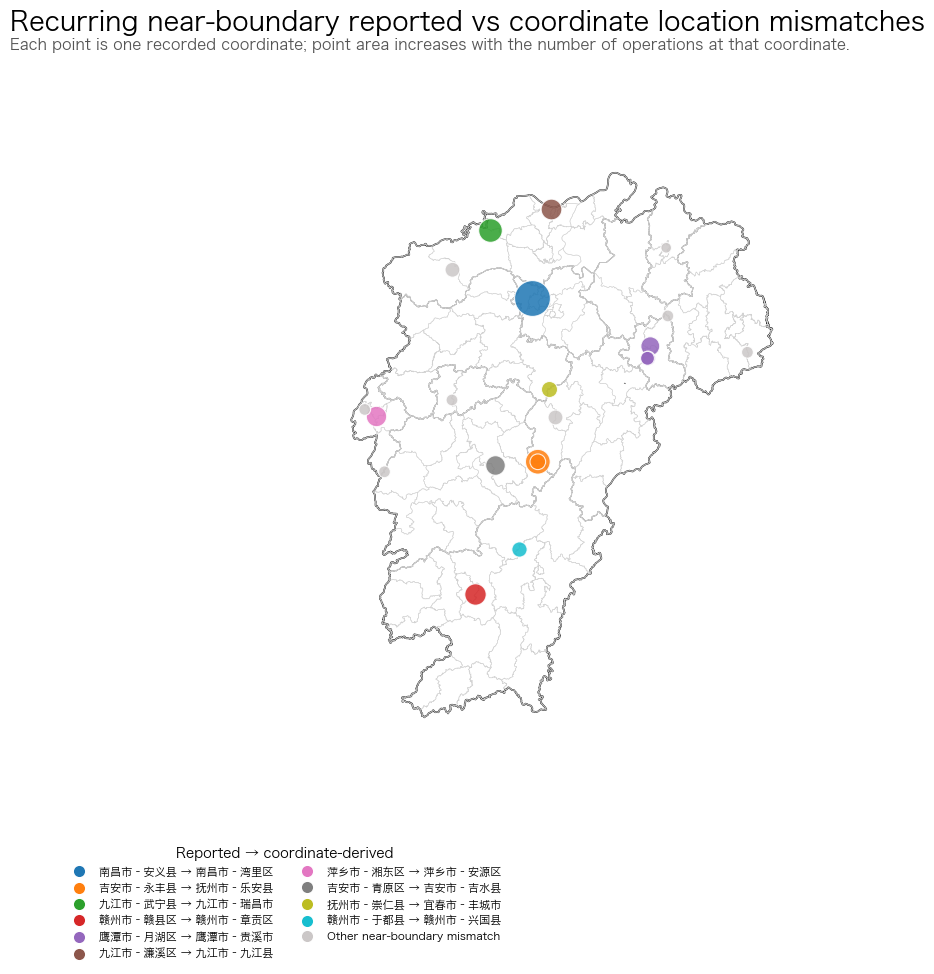

In [32]:
townships = gpd.read_file(data_dir / 'township_shapefile/xiangzhen.shp')
townships = townships.loc[townships['省'].eq('江西省'), ['市', '县', '乡', 'geometry']].copy()
province_boundary = townships.dissolve().boundary
city_boundaries = townships.dissolve(by='市').boundary
county_boundaries = townships.dissolve(by=['市', '县']).boundary

near_points = gpd.GeoDataFrame(
    near, geometry=gpd.points_from_xy(near['lon'], near['lat']), crs='EPSG:4326'
)
pair_counts = near_points.groupby('mismatch_pair')['records'].sum().sort_values(ascending=False)
top_pairs = pair_counts.index[:10].tolist()
near_points['map_pair'] = near_points['mismatch_pair'].where(
    near_points['mismatch_pair'].isin(top_pairs), 'Other near-boundary mismatch'
)

palette = list(plt.get_cmap('tab10').colors)
pair_order = top_pairs.copy()
colors = {
    pair: palette[i]
    for i, pair in enumerate(top_pairs)
}

if near_points['map_pair'].eq(
    'Other near-boundary mismatch'
).any():
    pair_order.append('Other near-boundary mismatch')
    colors['Other near-boundary mismatch'] = "#cbc7c7"

def marker_size(records):
    return 34 + 25 * (records ** 0.60)

fig, ax = plt.subplots(figsize=(12, 10))
province_boundary.plot(ax=ax, color='#222222', linewidth=1.2)
city_boundaries.plot(ax=ax, color='#a0a0a0', linewidth=0.65)
county_boundaries.plot(ax=ax, color='#d2d2d2', linewidth=0.35)
for pair in pair_order:
    group = near_points.loc[near_points['map_pair'].eq(pair)]
    group.plot(
        ax=ax, color=colors[pair], edgecolor='white', linewidth=0.8,
        markersize=group['records'].map(marker_size), alpha=0.86, zorder=3,
    )

pair_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor=colors[pair],
           markeredgecolor='white', markersize=9, label=pair)
    for pair in pair_order
]
fig.legend(
    handles=pair_handles,
    title='Reported → coordinate-derived',
    loc='lower left',
    bbox_to_anchor=(0.08, 0.02),
    frameon=False,
    fontsize=8,
    ncol=2,
)
fig.suptitle(
    'Recurring near-boundary reported vs coordinate location mismatches',
    fontsize=19,
    x=0.04,
    y=0.98,
    ha='left',
)
ax.set_axis_off()
fig.text(0.04,0.94,    
('Each point is one recorded coordinate; point area increases '
        'with the number of operations at that coordinate.'),
    fontsize=11,
    color='#555555',
)
plt.tight_layout(
    rect=[0.02, 0.23, 0.98, 0.90]
)
output_path = check_dir / 'near_boundary_mismatch_recurrence_map.png'
fig.savefig(output_path, dpi=220, bbox_inches='tight', facecolor='white')
print(output_path)


## Map interpretation

Near-boundary coordinate mismatches are more spread out across Jiangxi than the distant mismatch cases. However, the larger markers show that operation records are concentrated at a few recurring coordinates.

Most location pairs occur at 1 recorded coordinate. 月湖区 → 贵溪市 occurs at 3 nearby coordinates(they appear as 2 visible clusters because two coordinates overlap); the 永丰县 → 乐安县 pair occurs at 2 nearly overlapping coordinates. 

## Potential attrition problem from excluding near-boundary mismatches

The table shows how many operations in each spatially assigned county would be
removed if all near-boundary mismatches were excluded.

In [31]:
selection_full = cleaned.copy()
selection_near = near_records.copy()

selection_full['coordinate_county_group'] = (
    selection_full['county'].map(normalize_display_name)
)
selection_near['coordinate_county_group'] = (
    selection_near['county'].map(normalize_display_name)
)

all_county_records = (
    selection_full.groupby('coordinate_county_group')
    .size()
    .rename('All operation records')
)

near_county_records = (
    selection_near.groupby('coordinate_county_group')
    .size()
    .rename('Near-boundary records')
)

coordinate_county_attrition = pd.concat(
    [all_county_records, near_county_records],
    axis=1,
).fillna(0)

coordinate_county_attrition[
    'Near-boundary records'
] = coordinate_county_attrition[
    'Near-boundary records'
].astype(int)

coordinate_county_attrition = (
    coordinate_county_attrition.loc[
        coordinate_county_attrition[
            'Near-boundary records'
        ].gt(0)
    ]
    .copy()
)

coordinate_county_attrition['Share excluded'] = (
    coordinate_county_attrition['Near-boundary records']
    / coordinate_county_attrition['All operation records']
)

coordinate_county_attrition = (
    coordinate_county_attrition
    .reset_index()
    .rename(columns={
        'coordinate_county_group':
            'Coordinate-derived county',
    })
    .sort_values(
        ['Near-boundary records', 'Share excluded'],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

# Confirm that all 517 near-boundary records are represented.
assert (
    coordinate_county_attrition[
        'Near-boundary records'
    ].sum()
    == len(selection_near)
)

display(
    coordinate_county_attrition.style
    .hide(axis='index')
    .format({'Share excluded': '{:.1%}'})
    .set_caption(
        'Spatial attrition from excluding near-boundary mismatches'
    )
)

Coordinate-derived county,All operation records,Near-boundary records,Share excluded
湾里区,387,217,56.1%
乐安县,159,73,45.9%
瑞昌市,126,48,38.1%
章贡区,174,33,19.0%
贵溪市,237,33,13.9%
九江县,131,29,22.1%
安源区,59,27,45.8%
吉水县,107,23,21.5%
丰城市,87,10,11.5%
兴国县,228,8,3.5%


### Interpretation

Setting aside 珠山区(it has 100% exclusion rate but its denominator is only one operation), the four largest proportional reductions would occur in 湾里区, 乐安县,
安源区, and 瑞昌市:

- **湾里区:** 217 of 387 operations would be removed (56.1%).
- **乐安县:** 73 of 159 operations would be removed (45.9%).
- **安源区:** 27 of 59 operations would be removed (45.8%).
- **瑞昌市:** 48 of 126 operations would be removed (38.1%).

The proportional reductions are smaller in the rest of the counties, but some are still substantial. Therefore, although the near-boundary mismatched records are relatively dispersed around JX province, excluding all of them would likely lead to selection bias in our analysis.

#### Reported locations associated with the largest reductions

- The reduction in 湾里区 is associated with records reported as 安义县.
- The reduction in 乐安县 is primarily associated with records reported as
  永丰县, with a smaller contribution from records reported as 崇仁县.
- The reduction in 瑞昌市 is associated with records reported as 武宁县.
- The reduction in 安源区 is associated with records reported as 湘东区.